In [19]:
import pandas as pd
import psycopg2
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

import joblib
import matplotlib.pyplot as plt

In [20]:
DB = {
    "host": "rawg-db.cf0ec26s6wkm.eu-north-1.rds.amazonaws.com",
    "database": "postgres",
    "user": "rawg_admin",
    "password": "rawg2026-daniel",
    "port": 5432
}

In [21]:
conn = psycopg2.connect(**DB)

query = """
SELECT
    g.game_id,

    DATE_PART('day', NOW() - g.release_date) AS age_days,

    m.ratings_count,
    m.reviews_count,
    m.added,
    m.community_rating,

    COUNT(DISTINCT gp.platform_id) AS platform_count,
    COUNT(DISTINCT gt.tag_id) AS tag_count

FROM games g
JOIN game_metrics m ON g.game_id = m.game_id

LEFT JOIN game_platforms gp ON g.game_id = gp.game_id
LEFT JOIN game_tags gt ON g.game_id = gt.game_id

GROUP BY
    g.game_id, g.release_date,
    m.ratings_count, m.reviews_count,
    m.added, m.community_rating;
"""

df = pd.read_sql(query, conn)

conn.close()

print("Raw:", df.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_7072\3921776383.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Raw: (864423, 8)


In [22]:
# Remove invalid
df = df[df["age_days"].notna()]
df = df[df["age_days"] >= 0]

# Fill NA
df = df.fillna(0)

# Remove no-signal games
df = df[df["added"] > 0]

print("Clean:", df.shape)

Clean: (97424, 8)


In [23]:
# Remove invalid
df = df[df["age_days"].notna()]
df = df[df["age_days"] >= 0]

# Fill NA
df = df.fillna(0)

# Remove no-signal games
df = df[df["added"] > 0]

print("Clean:", df.shape)

Clean: (97424, 8)


In [24]:
p80 = df["added"].quantile(0.8)

df["success"] = (df["added"] >= p80).astype(int)

print("Success rate:", df["success"].mean())

Success rate: 0.20121325340778454


In [25]:
FEATURES = [
    "age_days",
    "ratings_count",
    "reviews_count",
    "community_rating",
    "platform_count",
    "tag_count"
]

X = df[FEATURES]
y = df["success"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [28]:
p = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, p)
f1 = f1_score(y_test, p > 0.5)

print("AUC:", round(auc,4))
print("F1 :", round(f1,4))

print(classification_report(y_test, p > 0.5))

AUC: 0.9604
F1 : 0.7985
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     15564
           1       0.86      0.75      0.80      3921

    accuracy                           0.92     19485
   macro avg       0.90      0.86      0.88     19485
weighted avg       0.92      0.92      0.92     19485



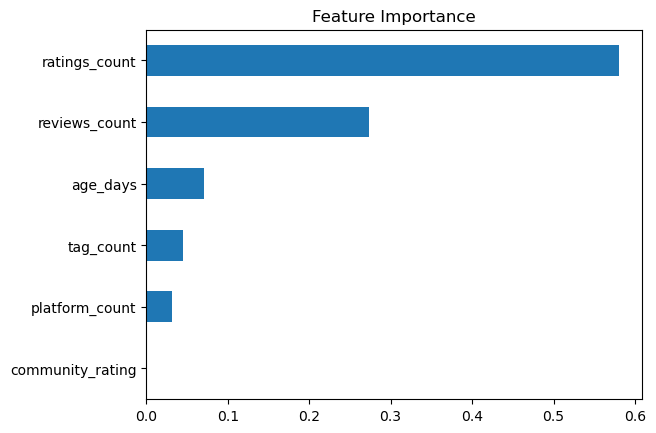

In [29]:
imp = pd.Series(
    model.feature_importances_,
    index=FEATURES
).sort_values()

imp.plot(kind="barh", title="Feature Importance")
plt.show()

In [30]:
joblib.dump(model, "rawg_popularity_model.pkl")
joblib.dump(FEATURES, "rawg_features.pkl")

print("Model saved")

Model saved
